P_d vals = [0.015795981755939437, 0.09401726733804239, 0.17223849173575445, 0.2504596549490756, 0.3286807569780059, 0.4069017978225453, 0.48512277748269383, 0.5633436959584515, 0.641564553238716, 0.7197853493456918, 0.7980060842571746, 0.8762267579953686, 0.9544473705380696, 1.0326679218963797, 1.1108884120702989, 1.1891088410598272, 1.2673292088649646, 1.3455495154857111, 1.4237697609220668, 1.5019899451740315, 1.5802100682416054, 1.6584301301136861, 1.7366501308124782, 1.8148700703268794, 1.8930899486457875, 1.971309765791407, 2.0495295217526355, 2.127749216518371, 2.2059688501108177, 2.2841884225188736, 2.3624079337314363, 2.4406273837707104, 2.5188467726255936, 2.5970661002849837, 2.675285366771085, 2.7535045720727958, 2.831723716179013, 2.909942799111942, 2.98816182086048, 3.066380781424627, 3.144599680804383, 3.2228185189997482, 3.3010372960107226, 3.379256011837306, 3.4574746664794986, 3.5356932599373003, 3.613911792210711, 3.6921302633108333, 3.7703486732154623, 3.8485670219468

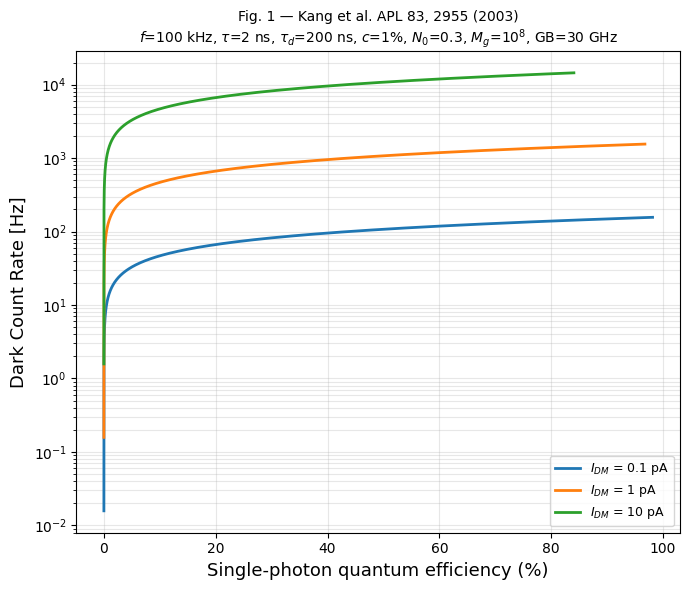

Done.


In [ ]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# =============================================================================
# Kang et al. APL 83, 2955 (2003) — Fig. 1 reproduction
# Dark Count Probability (P_d) vs SPQE, parametric in I_DM
# =============================================================================

# --- Fixed parameters from Fig. 1 caption ---
f       = 100e3          # Repetition rate [Hz]
Delta_T = 1.0 / f        # Period between pulses [s]
tau     = 2e-9           # Gate pulse width [s]
tau_d   = 200e-9         # Carrier detrap time constant [s]
c       = 0.01           # Trapping ratio (1%)
N0      = 0.3            # Mean photons per pulse
Mg      = 1e8            # Geiger mode gain
GB      = 30e9           # Gain-bandwidth product [Hz]
q       = 1.602e-19      # Electron charge [C]

# Effective transit time (Eq. 3): tau_tr* = M0 / (2*pi*GB)
# But M0 (dc gain) is a free parameter for the device. 
# The paper says tau_tr* is dominated by avalanche buildup, tau_tr* = Mg/(2*pi*GB)
# Actually tau_tr* = M0/(2*pi*GB) where M0 is dc gain. 
# For a SPAD operating near breakdown, M0 ~ 10-30 is typical.
M0      = 10             # DC avalanche gain
tau_tr  = M0 / (2 * np.pi * GB)   # Effective transit time [s]

# --- Afterpulse parameters ---
# N_tr = c * Mg / (1 - c)  [avg carriers trapped per pulse]
N_tr = c * Mg / (1 - c)

# --- Precompute afterpulse exponential factors (Eqs. 4 & 5) ---
# These don't depend on P_a or I_DM
exp_tau_taud   = np.exp(tau / tau_d)
exp_DT_taud    = np.exp(Delta_T / tau_d)
exp_tautr_taud = np.exp(tau_tr / tau_d)

factor_Nt1 = (exp_tau_taud - 1) / (exp_DT_taud - 1)      # Eq. (4) factor
factor_Nt2 = (exp_tautr_taud - 1) / (exp_DT_taud - 1)    # Eq. (5) factor

# P_ph = probability pulse has at least one photon
P_ph = 1 - np.exp(-N0)

# --- P_a sweep (triggering probability, the free parameter) ---
Pa_values = np.linspace(1e-4, 0.99, 2000)

fig, ax = plt.subplots(figsize=(7, 6))

I_DM_list   = [0.1e-12, 1e-12, 10e-12]
labels      = ['$I_{DM}$ = 0.1 pA', '$I_{DM}$ = 1 pA', '$I_{DM}$ = 10 pA']
linestyles  = ['-', '-', '-']

for I_DM, label in zip(I_DM_list, labels):

    # --- N_DM1 and N_DM2 (Eqs. 2 & 3) ---
    N_DM1 = I_DM * tau / q           # Primary dark carriers during pulse
    N_DM2 = I_DM * M0 * tau_tr / q  # Dark carriers generated before pulse

    Pd_vals   = []
    SPQE_vals = []

    for Pa in Pa_values:
        # --- Solve Eq. (7) self-consistently for P_d ---
        # P_d = 1 - exp(-N_d * Pa)
        # N_d = N_DM1 + N_DM2 + N_t1(Pd) + N_t2(Pd)   [Eq. 6]
        # N_t1 = Pd * N_tr * factor_Nt1                 [Eq. 4]
        # N_t2 = Pd * N_tr * factor_Nt2                 [Eq. 5]
        # => N_d = N_DM1 + N_DM2 + Pd * N_tr * (factor_Nt1 + factor_Nt2)

        def equation(Pd):
            Nd = (N_DM1 + N_DM2
                  + Pd * N_tr * factor_Nt1
                  + Pd * N_tr * factor_Nt2)
            return Pd - (1 - np.exp(-Nd * Pa))

        # Solve numerically
        Pd_sol = fsolve(equation, x0=N_DM1 * Pa, full_output=False)[0]
        Pd_sol = float(np.clip(Pd_sol, 0, 1))

        # --- Now compute P_on using Eq. (11) ---
        # N'_t1 and N'_t2 use P_on instead of P_d in Eqs. (4) & (5)
        # eta * N0 term accounts for optical carriers
        # Solve Eq. (11) self-consistently for P_on

        eta = Pa  # In the paper eta (QE of absorption layer) × Pa gives SPQE;
                  # here we treat Pa as the combined triggering probability
                  # and eta as the intrinsic absorption QE.
                  # For simplicity and to match the paper's parametric plot,
                  # we use SPQE = (P_on - P_d) / P_ph  [Eq. 8]

        def equation_on(Pon):
            Nd_on = (N_DM1 + N_DM2
                     + Pon * N_tr * factor_Nt1
                     + Pon * N_tr * factor_Nt2
                     + Pa * N0)           # eta*N0 term, eta absorbed into Pa
            return Pon - (1 - np.exp(-Nd_on * Pa))

        Pon_sol = fsolve(equation_on, x0=(N_DM1 + Pa * N0) * Pa,
                         full_output=False)[0]
        Pon_sol = float(np.clip(Pon_sol, 0, 1))

        # SPQE = (P_on - P_d) / P_ph   [Eq. 8]
        SPQE = (Pon_sol - Pd_sol) / P_ph

        Pd_vals.append(Pd_sol) # times by f
        SPQE_vals.append(SPQE * 100)   # convert to %

    print(f"P_d vals = {Pd_vals}")
    ax.semilogy(SPQE_vals, Pd_vals, lw=2, label=label)

# # --- Overlay approximate measured device points from Fig. 1 ---
# # EG&G InGaAs APD at 240K, I_DM=5pA
# measured_EGG  = [(10, 3e-4), (20, 2e-3), (30, 2e-2)]
# # NEC NDL3351P at 130K, I_DM=0.1pA
# measured_NEC  = [(10, 3e-6), (20, 8e-5), (30, 2e-3)]

# ax.plot(*zip(*measured_EGG), 'v--', color='C1',
#         label='EG&G InGaAs (measured, $I_{DM}$=5 pA)', ms=7)
# ax.plot(*zip(*measured_NEC), '^--', color='C0',
#         label='NEC NDL3351P (measured, $I_{DM}$=0.1 pA)', ms=7)

ax.set_xlabel('Single-photon quantum efficiency (%)', fontsize=13)
ax.set_ylabel('Dark Count Probability per Pulse', fontsize=13)
ax.set_title('Fig. 1 — Kang et al. APL 83, 2955 (2003)\n'
             r'$f$=100 kHz, $\tau$=2 ns, $\tau_d$=200 ns, '
             r'$c$=1%, $N_0$=0.3, $M_g$=10$^8$, GB=30 GHz',
             fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim([0, 40])
ax.set_ylim([1e-7, 1e0])
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/dcr_spde.png', dpi=150)
plt.show()
print("Done.")